<a href="https://colab.research.google.com/github/rituraj735/HeadCue/blob/main/Ritu's_Copy_of_DataSetTest(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

from google.colab import drive
drive.mount('/content/drive')

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

section_dict = {}

for i in range (1, 25):
  section_dict[i] = list()

# gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu", "mouth-stretch-imu"] # need to explore other gestures based on their graphs
gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu"] # need to explore other gestures based on their graphs

def scale_columns(df): # here we scale the columns of the accelerometer data by multiplying it by a factor of 0.061
  for col in df.columns:
    if col.startswith('a'):
      df[col] = df[col] * 0.061
  return df

root_location = "/content/drive/MyDrive/Wireless project/P"
for i in range(1,25):
  if (i == 2):
    continue
  for files in os.listdir(root_location + str(i)):
    if (files[2:len(files)-9] not in gestures and files[3: len(files)-9] not in gestures):
      continue
    if files.endswith("right.csv"):
      continue
    df = pd.read_csv(os.path.join(root_location + str(i), files))
    #apply scaling here for simplicity
    df = df.pipe(scale_columns)
    df_sorted = df.sort_values(by='timestamp')
    df = df_sorted.reset_index(drop=True) # when sorting of data frame happens in previous lines based on the timestamp the order of the old dataframe will be changed, it will become 5,1, 2, 4 etc. we reset the index with reset_index=True and then say drop=True so that the old index is dropped and the new one is adopted
    if (i> 0 and i< 10):
      section_dict[i].append((df, files[2:len(files)-9]))
    else:
      section_dict[i].append((df, files[3:len(files)-9]))


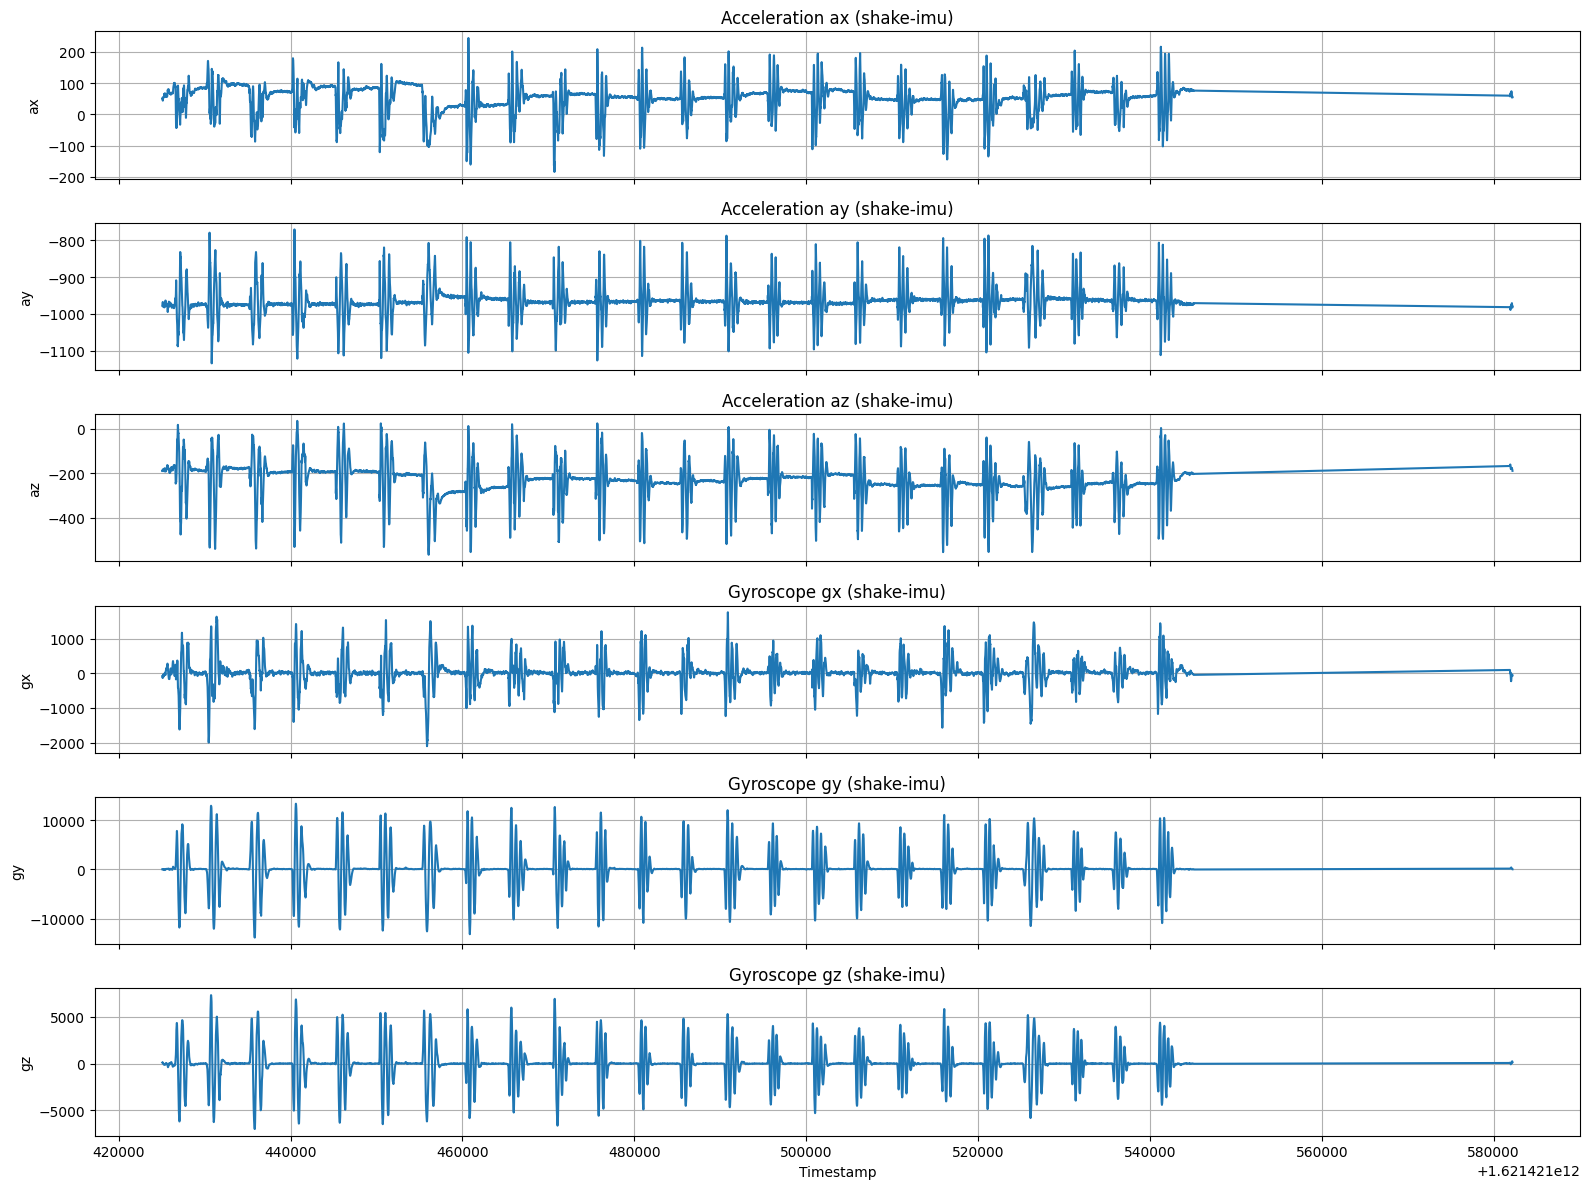

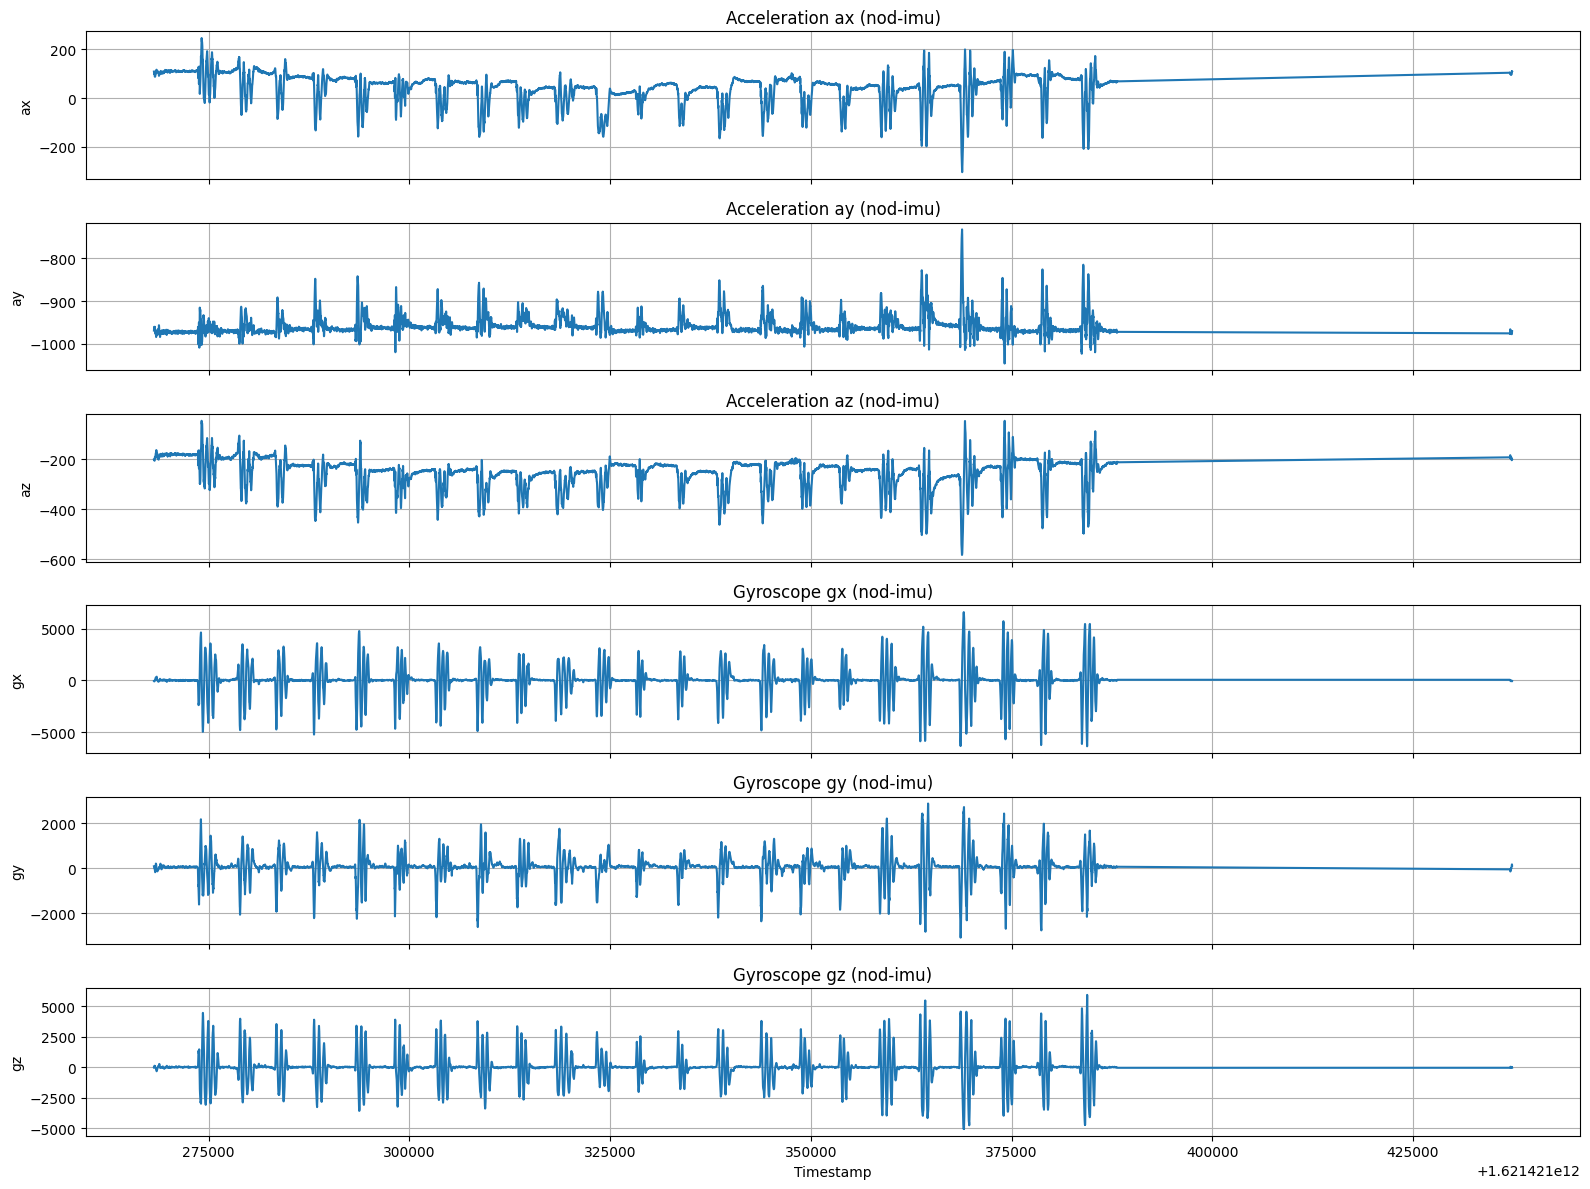

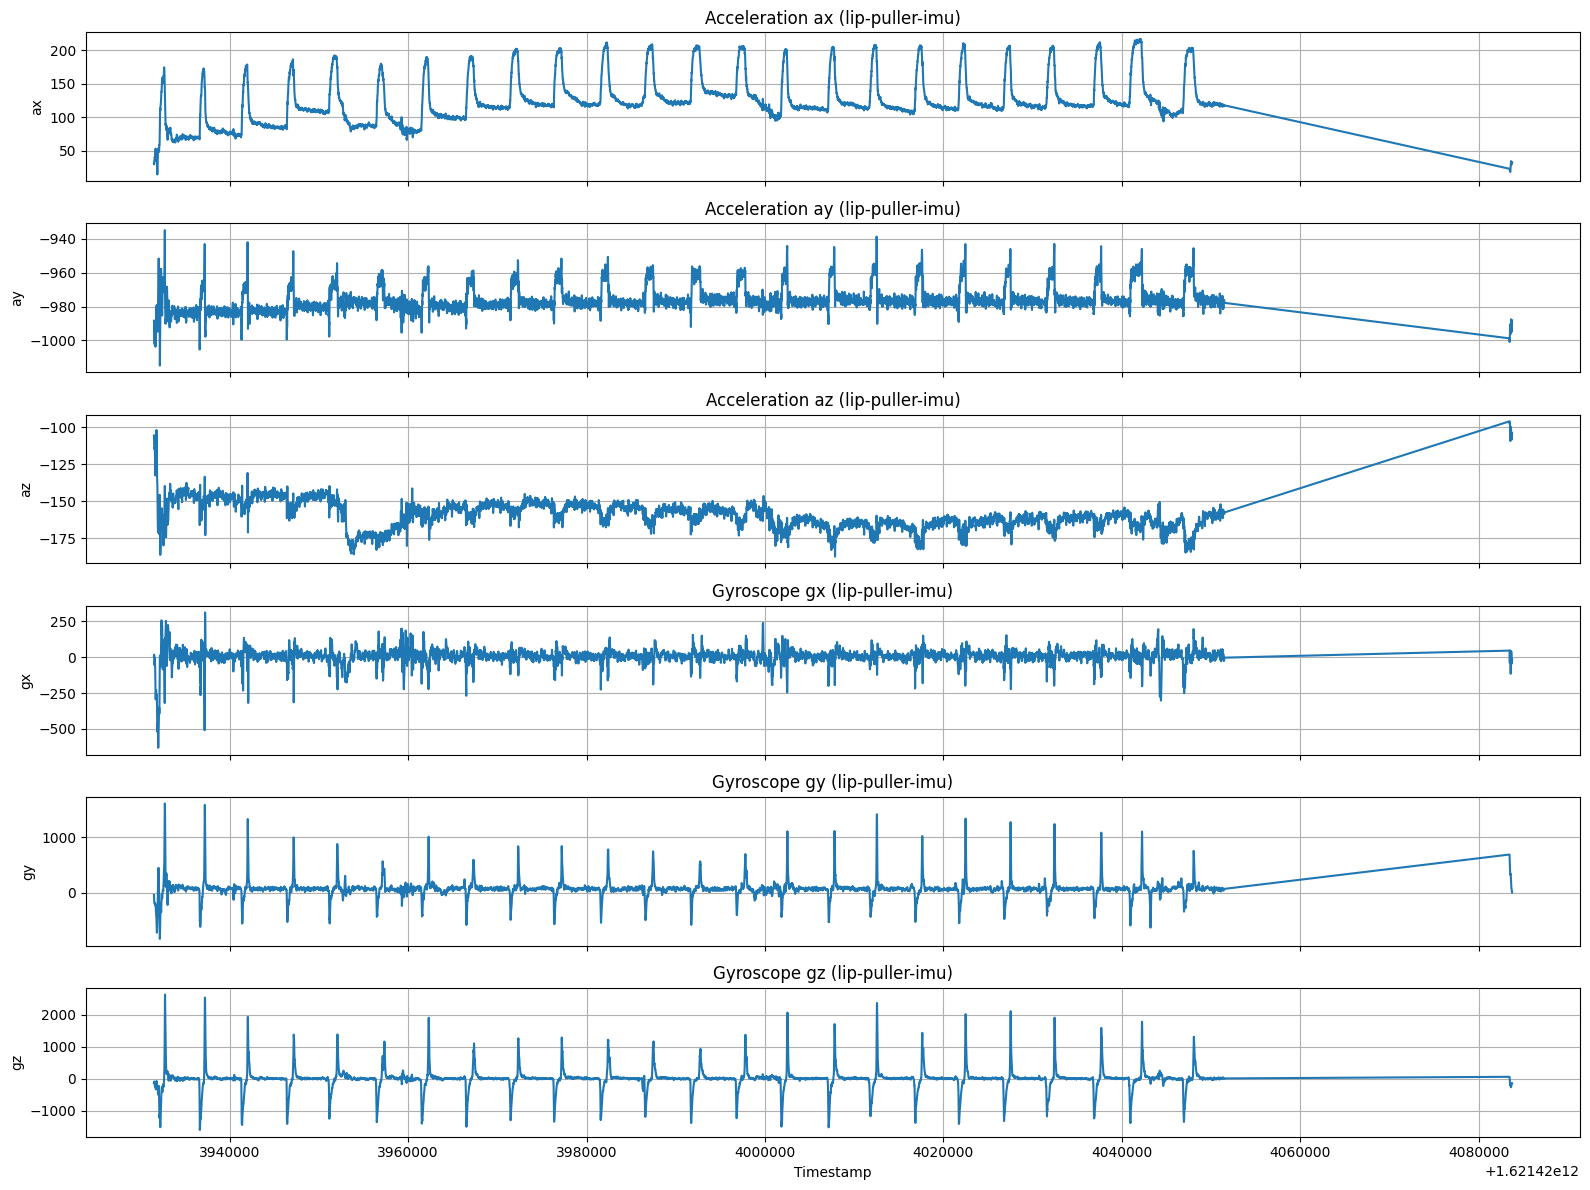

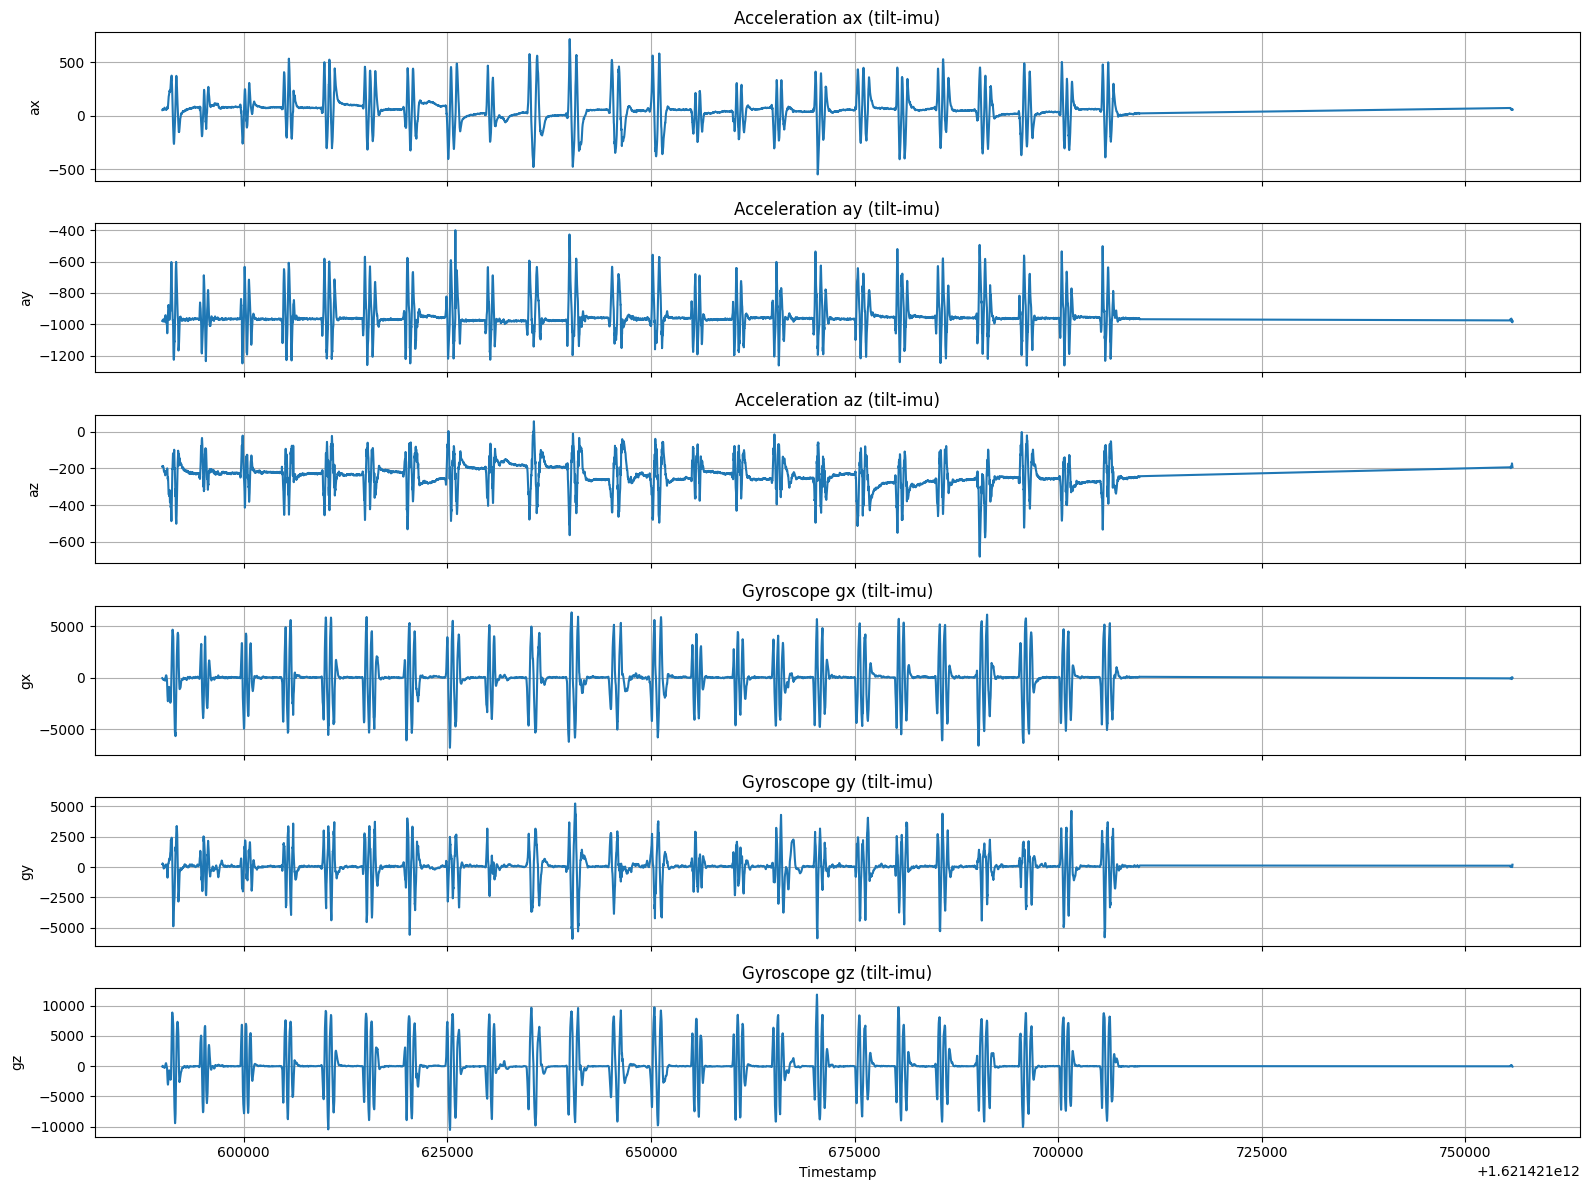

In [19]:
# this frame is for plotting each imu gestures for each individual on the same plot
import matplotlib.pyplot as plt

def plot_all_imu_data(plot_list, participant_id, filename_to_plot):
  df = None
  for p_id, data_entries in plot_list.items():
    if p_id == participant_id:
      for d_frame, f_name in data_entries:
        if f_name == filename_to_plot:
          df = d_frame
          break
      if df is not None:
        break
  fig, axes = plt.subplots(6, 1, figsize=(16,12), sharex = True)

  accel_cols = ['ax', 'ay', 'az']
  gyro_cols = ['gx', 'gy', 'gz']
  all_cols = accel_cols + gyro_cols

  for i, col in enumerate(all_cols):
    axes[i].plot(df['timestamp'], df[col], label=col)
    axes[i].set_ylabel(col)
    axes[i].grid(True) # set it to false later to check what it does
    if col in accel_cols:
      axes[i].set_title(f'Acceleration {col} ({filename_to_plot})')
    else:
      axes[i].set_title(f'Gyroscope {col} ({filename_to_plot})')

  axes[-1].set_xlabel('Timestamp')
  plt.tight_layout()
  plt.show()



#call
plot_all_imu_data(section_dict, 1, "shake-imu")
plot_all_imu_data(section_dict, 1, "nod-imu")
plot_all_imu_data(section_dict, 1, "lip-puller-imu")
plot_all_imu_data(section_dict, 1, "tilt-imu")
# plot_all_imu_data(section_dict, 1, "mouth-stretch-imu")

## Old features calculation

In [35]:
def mean_crossing_rate(data_series):
  mean_value = np.mean(data_series) # this line calculates the mean of all values in the data series
  crossings = np.where(np.diff(np.sign(data_series - mean_value)))[0]
  mcr = len(crossings) / len(data_series)
  return mcr

def extract_features_with_tag(df, filename):
  features = {}
  numeric_cols = df.select_dtypes(include=np.number).columns.drop('timestamp', errors='ignore')

  for col in numeric_cols:
    features[f'{col}_mean'] = df[col].mean()
    features[f'{col}_std'] = df[col].std()
    if (col == 'gy'):
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))
      features[f'{col}_mean_crossing_rate'] = mean_crossing_rate(df[col])

    if len(numeric_cols) >= 3:
      corr_matrix = df[numeric_cols].corr()

      #Extract specific correlations
      if 'ax' in numeric_cols and 'ay' in numeric_cols:
        features['ax_ay_corr'] = corr_matrix.loc['ax','ay']
      if 'ax' in numeric_cols and 'az' in numeric_cols:
        features['ax_az_corr'] = corr_matrix.loc['ax', 'az']
      if 'ay' in numeric_cols and 'az' in numeric_cols:
          features['ay_az_corr'] = corr_matrix.loc['ay', 'az']
      if 'gx' in numeric_cols and 'gy' in numeric_cols:
          features['gx_gy_corr'] = corr_matrix.loc['gx', 'gy']
      if 'gx' in numeric_cols and 'gz' in numeric_cols:
          features['gx_gz_corr'] = corr_matrix.loc['gx', 'gz']
      if 'gy' in numeric_cols and 'gz' in numeric_cols:
          features['gy_gz_corr'] = corr_matrix.loc['gy', 'gz']

  features['classification_tag'] = filename
  return features




In [36]:
# this block shows how my features data frame will look like
all_features = []
for data_list in section_dict.values():
  for df, filename in data_list:
    features = extract_features_with_tag(df, filename)
    all_features.append(features)

features_df = pd.DataFrame(all_features)
display(features_df)


,ax_mean,ax_std,ax_ay_corr,ax_az_corr,ay_az_corr,gx_gy_corr,gx_gz_corr,gy_gz_corr,ay_mean,ay_std,...,az_std,gx_mean,gx_std,gy_mean,gy_std,gy_rms,gy_mean_crossing_rate,gz_mean,gz_std,classification_tag
0,52.690375,45.879881,-0.720480,0.731529,-0.945991,0.814959,0.802831,0.990454,-965.800222,39.318714,...,80.090419,13.378669,372.731197,60.920230,3536.709770,3537.093366,0.055520,1.077457,1720.303984,shake-imu
1,123.690232,33.557946,0.851000,-0.399541,-0.439649,-0.022010,0.050198,0.889727,-975.896834,7.163343,...,9.296010,4.492139,54.813722,70.694438,156.890187,172.076349,0.082994,3.109808,330.540843,lip-puller-imu
2,51.595141,140.304355,0.860644,-0.838156,-0.792907,-0.655732,0.972210,-0.579791,-950.744223,98.726126,...,74.399300,-48.176029,1818.320572,35.879748,1158.857715,1159.366809,0.042930,37.429780,3086.305874,tilt-imu
3,44.197888,60.841893,-0.798976,0.924857,-0.877795,0.863303,-0.975959,-0.880628,-957.792561,22.906096,...,59.667320,7.271625,1442.886062,55.201005,562.088055,564.769795,0.053304,-1.305298,1183.946621,nod-imu
4,-73.540379,39.214333,0.275436,0.506854,0.760849,-0.229765,-0.051327,-0.293759,-973.207394,6.478224,...,41.479408,30.586452,123.185140,34.121998,90.517270,96.731759,0.089524,8.833400,204.973278,lip-puller-imu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,-0.089697,155.922828,0.907746,-0.864225,-0.797075,-0.937149,0.951592,-0.907419,-875.784868,73.852623,...,77.862248,-0.202840,1464.225190,141.922390,1546.571420,1553.008157,0.051368,12.625588,1925.966355,tilt-imu
88,-341.779806,29.909603,0.584018,0.205511,0.783537,-0.994079,0.693723,-0.684838,846.934550,18.652005,...,62.274161,129.096039,1162.615756,13.241173,2156.561647,2156.516357,0.062166,-17.420658,335.699100,shake-imu
89,-351.847256,22.355559,0.423465,-0.382217,0.603617,0.334883,0.420722,0.847688,831.108520,11.166001,...,20.231514,57.003188,65.917393,110.661380,211.842779,238.997338,0.102965,13.118027,157.569083,lip-puller-imu
90,-358.393130,204.098662,0.881843,0.170836,0.237163,-0.530697,-0.331550,0.120062,836.630809,87.268433,...,44.968861,100.337400,419.753884,14.952073,449.019434,449.250418,0.069378,-13.395375,2802.866919,tilt-imu


# Task
Convert the time domain data in the dataframes within the lists `p1`, `p2`, `p3`, `p4`, and `p5` to the frequency domain using Fast Fourier Transform (FFT).

## Define fft function

### Subtask:
Create a function to perform the FFT on a given column of a dataframe. This function should handle potential issues like non-uniform timestamps if necessary.


**Reasoning**:
Define the `perform_fft` function to calculate the FFT of a time series and its corresponding frequencies.



In [37]:
import numpy as np

def perform_fft(data_series, timestamp_series):
  time_diffs = np.diff(timestamp_series)
  sampling_rate = 1000 # we have assumed sampling rate over here, should we use the median technique to calculate it?
  fft_results = np.fft.fft(data_series)
  frequencies = np.fft.fftfreq(len(data_series), d=1.0/sampling_rate)
  return np.abs(fft_results), frequencies

# this functions returns the frequencies (X-axis) and their magnitudes (Y-axis)

## Apply fft to all dataframes

### Subtask:
Iterate through the `p1`, `p2`, `p3`, `p4`, and `p5` lists and apply the FFT function to each relevant column (excluding 'timestamp') in each dataframe.


**Reasoning**:
Initialize dictionaries to store the frequency domain data for each participant list and iterate through the lists and dataframes to apply the FFT function to relevant columns.



In [38]:
fft_results_dict = {}

for part_idx, data_list in section_dict.items():
  fft_results_dict[part_idx] = {}
  for df, filename in data_list:
    file_key = f'{filename}'
    fft_results_dict[part_idx][file_key] = {}
    for col in df.select_dtypes(include=np.number).columns:
      if col == 'timestamp':
        continue
      magnitudes, frequencies = perform_fft(df[col], df['timestamp'])
      fft_results_dict[part_idx][file_key][col] = {
          'magnitudes': magnitudes,
          'frequencies': frequencies
      }

print(fft_results_dict)

# this portion of code performs fft on each df and then stores the result of in fft_results_dict

{1: {'shake-imu': {'ax': {'magnitudes': array([660526.544     ,  39523.02307987,  86530.35597118, ...,
        15341.42618137,  86530.35597118,  39523.02307987]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'ay': {'magnitudes': array([1.21072716e+07, 1.75916696e+04, 3.70981295e+04, ...,
       1.15312334e+04, 3.70981295e+04, 1.75916696e+04]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'az': {'magnitudes': array([2908279.676     ,   98587.9592939 ,  169465.96001917, ...,
         41661.06870528,  169465.96001917,   98587.9592939 ]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052, ..., -0.23931078,
       -0.15954052, -0.07977026])}, 'gx': {'magnitudes': array([167715.        ,  39750.09409937,  51324.70328649, ...,
        34052.45709508,  51324.70328649,  39750.09409937]), 'frequencies': array([ 0.        ,  0.07977026,  0.15954052,

## Store frequency domain data

### Subtask:
Decide how to store the resulting frequency domain data. This could be in new dataframes, or by adding new columns to the existing dataframes.


**Reasoning**:
Based on the existing `features_df` which contains time-domain features for each file, and the need for subsequent analysis or machine learning, it makes sense to augment this DataFrame with aggregated frequency-domain features rather than creating entirely new DataFrames. This keeps all features for a single file in one place. I will extract relevant features from the FFT results and add them as new columns to `features_df`.



# Calculating merged features here

In [64]:
def calculate_merged_features(df, filename):
  features = {}
  numeric_cols = df.select_dtypes(include=np.number).columns.drop('timestamp', errors='ignore')

  for col in numeric_cols:
    if (col == 'gy'):
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))

  if len(numeric_cols) >= 3:
    corr_matrix = df[numeric_cols].corr()

    #Extract specific correlations
    if 'ax' in numeric_cols and 'ay' in numeric_cols:
      features['ax_ay_corr'] = corr_matrix.loc['ax','ay']
    if 'ax' in numeric_cols and 'az' in numeric_cols:
      features['ax_az_corr'] = corr_matrix.loc['ax', 'az']
    if 'ay' in numeric_cols and 'az' in numeric_cols:
        features['ay_az_corr'] = corr_matrix.loc['ay', 'az']
    if 'gx' in numeric_cols and 'gy' in numeric_cols:
        features['gx_gy_corr'] = corr_matrix.loc['gx', 'gy']
    if 'gx' in numeric_cols and 'gz' in numeric_cols:
        features['gx_gz_corr'] = corr_matrix.loc['gx', 'gz']
    if 'gy' in numeric_cols and 'gz' in numeric_cols:
        features['gy_gz_corr'] = corr_matrix.loc['gy', 'gz']

  time_diffs = np.diff(df['timestamp'])
  median_diff_sec = np.median(time_diffs) / 1000
  sampling_rate = 1/ median_diff_sec if median_diff_sec > 0 else 50

  for col in numeric_cols:
    fft_vals = np.fft.fft(df[col].values)
    freqs = np.fft.fftfreq(len(df[col]), d= median_diff_sec)

    magnitude = np.abs(fft_vals)
    pos_mask = freqs > 0
    freqs = freqs[pos_mask]
    magnitude = magnitude[pos_mask]

    if len(magnitude) > 0 :
      dom_freq_idx = np.argmax(magnitude)
      features[f'{col}_dom_freq'] = freqs[dom_freq_idx]
      features[f'{col}_energy'] = np.sum(magnitude**2)
    else: # Ensure features are always present, even if magnitude is empty
      features[f'{col}_dom_freq'] = 0.0 # Use 0.0 or np.nan as a placeholder
      features[f'{col}_energy'] = 0.0 # Use 0.0 or np.nan as a placeholder

  features['classification_tag'] = filename
  return features

all_features_rows = []
for person_id, files in section_dict.items():
  for df, gesture_name in files:
    row_features = calculate_merged_features(df, gesture_name)
    row_features['person_id'] = person_id
    all_features_rows.append(row_features)

merged_df = pd.DataFrame(all_features_rows)
display(merged_df.head())

,gy_rms,ax_ay_corr,ax_az_corr,ay_az_corr,gx_gy_corr,gx_gz_corr,gy_gz_corr,ax_dom_freq,ax_energy,ay_dom_freq,...,az_dom_freq,az_energy,gx_dom_freq,gx_energy,gy_dom_freq,gy_energy,gz_dom_freq,gz_energy,classification_tag,person_id
0,3537.093366,-0.720480,0.731529,-0.945991,0.814959,0.802831,0.990454,0.191449,1.653857e+11,1.707084,...,0.015954,5.039813e+11,1.834716,1.091553e+13,1.707084,9.827706e+14,1.707084,2.325218e+14,shake-imu,1
1,172.076349,0.851000,-0.399541,-0.439649,-0.022010,0.050198,0.889727,0.191525,8.840922e+10,0.191525,...,0.007980,6.784221e+09,0.191525,2.358769e+11,0.383050,1.932406e+12,0.383050,8.577428e+12,lip-puller-imu,1
2,1159.366809,0.860644,-0.838156,-0.792907,-0.655732,0.972210,-0.579791,1.324609,1.545676e+12,1.731567,...,0.007980,4.346241e+11,1.540057,2.596074e+14,1.460262,1.054475e+14,1.540057,7.479181e+14,tilt-imu,1
3,564.769795,-0.798976,0.924857,-0.877795,0.863303,-0.975959,-0.880628,0.191510,2.906575e+11,0.191510,...,0.191510,2.795433e+11,1.524098,1.634708e+14,1.723588,2.480760e+13,1.524098,1.100628e+14,nod-imu,1
4,96.731759,0.275436,0.506854,0.760849,-0.229765,-0.051327,-0.293759,0.015958,1.207633e+11,0.007979,...,0.007979,1.351172e+11,0.191494,1.191687e+12,0.327136,6.434404e+11,0.279263,3.299438e+12,lip-puller-imu,3


Overall Accuracy: 0.9239130434782609
Overall Classification Report:
                precision    recall  f1-score   support

lip-puller-imu       0.92      1.00      0.96        23
       nod-imu       0.88      0.91      0.89        23
     shake-imu       0.95      0.78      0.86        23
      tilt-imu       0.96      1.00      0.98        23

      accuracy                           0.92        92
     macro avg       0.93      0.92      0.92        92
  weighted avg       0.93      0.92      0.92        92



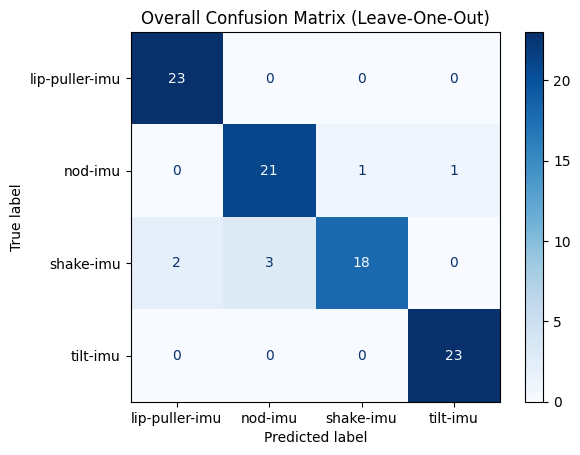

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt


X = merged_df.drop(['classification_tag','person_id'], axis=1)
y = merged_df['classification_tag']

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
svm_model = SVC(kernel='linear')

for train_index, test_index in loo.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  scaler = StandardScaler()
  X_train = scaler.fit_transform(X_train)
  X_test  = scaler.transform(X_test)

  svm_model.fit(X_train, y_train)

  y_pred = svm_model.predict(X_test)

  y_true_all.extend(y_test)
  y_pred_all.extend(y_pred)

accuracy = accuracy_score(y_true_all, y_pred_all)
print(f"Overall Accuracy: {accuracy}")
print("Overall Classification Report:")
print(classification_report(y_true_all, y_pred_all))

overall_cm = confusion_matrix(y_true_all, y_pred_all)
disp_overall = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=svm_model.classes_)
disp_overall.plot(cmap=plt.cm.Blues)
plt.title('Overall Confusion Matrix (Leave-One-Out)')
plt.show()


In [55]:
# Get the exact column order for the server
print("COPY THIS LIST EXACTLY:")
print(X.columns.tolist())

COPY THIS LIST EXACTLY:
['gy_rms', 'ax_ay_corr', 'ax_az_corr', 'ay_az_corr', 'gx_gy_corr', 'gx_gz_corr', 'gy_gz_corr', 'ax_dom_freq', 'ax_energy', 'ay_dom_freq', 'ay_energy', 'az_dom_freq', 'az_energy', 'gx_dom_freq', 'gx_energy', 'gy_dom_freq', 'gy_energy', 'gz_dom_freq', 'gz_energy']


In [56]:
expected_feature_columns = X.columns # Get the feature names and order from the training data X

# Instantiate the StandardScaler once, outside the loop, and fit it on the entire training data (X).
# For this demonstration, we'll refit it on `X` in this cell, as it wasn't explicitly saved from `qaaB1kwf3cib`.
# In a production setting, `final_scaler` should be saved after training.
final_scaler_for_prediction = StandardScaler()
final_scaler_for_prediction.fit(X) # Fit on the entire training dataset
y_test_true_all = []
y_test_pred_all = []

for i in range(25, 30):
  print(f"\nParticipant {i}, Gesture: {gesture} ---->")
  for gesture in gestures:

    test_frame = pd.read_csv(f"/content/drive/MyDrive/Wireless project/P{i}/{i}-{gesture}-left.csv")
    test_frame = test_frame.pipe(scale_columns) # Apply scaling as done for training data
    time_feature = calculate_merged_features(test_frame, gesture)

    time_feature_df = pd.DataFrame(time_feature, index=[0])
    y_actual = time_feature_df['classification_tag']

    X_test_temp = time_feature_df.drop('classification_tag', axis=1)

    # Reindex X_test to match the training feature order and ensure all columns are present
    # Fill missing columns (if any, though should be none after fix in calculate_merged_features) with 0
    X_test = X_test_temp.reindex(columns=expected_feature_columns, fill_value=0)

    # Transform X_test using the scaler fitted on the training data
    X_test = final_scaler_for_prediction.transform(X_test)

    y_pred = svm_model.predict(X_test)
    y_test_true_all.extend(y_actual)
    y_test_pred_all.extend(y_pred)

    print(y_pred, y_actual)
print("============================================")
accuracy = accuracy_score(y_test_true_all, y_test_pred_all)
print(f"Unseen Accuracy: {accuracy}")



Participant 25, Gesture: tilt-imu ---->
['tilt-imu'] 0    shake-imu
Name: classification_tag, dtype: object
['nod-imu'] 0    nod-imu
Name: classification_tag, dtype: object
['tilt-imu'] 0    lip-puller-imu
Name: classification_tag, dtype: object
['tilt-imu'] 0    tilt-imu
Name: classification_tag, dtype: object

Participant 26, Gesture: tilt-imu ---->
['shake-imu'] 0    shake-imu
Name: classification_tag, dtype: object
['nod-imu'] 0    nod-imu
Name: classification_tag, dtype: object
['lip-puller-imu'] 0    lip-puller-imu
Name: classification_tag, dtype: object
['tilt-imu'] 0    tilt-imu
Name: classification_tag, dtype: object

Participant 27, Gesture: tilt-imu ---->
['shake-imu'] 0    shake-imu
Name: classification_tag, dtype: object
['nod-imu'] 0    nod-imu
Name: classification_tag, dtype: object
['lip-puller-imu'] 0    lip-puller-imu
Name: classification_tag, dtype: object
['shake-imu'] 0    tilt-imu
Name: classification_tag, dtype: object

Participant 28, Gesture: tilt-imu ---->
['

## Save the model for Flask server

In [57]:
import joblib

#Saving the model
joblib.dump(svm_model, 'gesture_svm.pkl')

#Saving the fitted scaler so that the raw sensor data makes sense to the app
joblib.dump(scaler, 'gesture_scaler.pkl')

print("Brain of the model saved!")


Brain of the model saved!


In [1]:
!pip install flask pyngrok --ignore-installed blinker

  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pyngrok-7.5.0-py3-none-any.whl.metadata (8.1 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
Using cached flask-3.1.2-py3-none-any.whl (103 kB)
Using cached pyngrok-7.5.0-py3-none-any.whl (24 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached jinja2-3.1.6-py3

In [2]:
!ngrok authtoken 35oKbxLEmAymq3JH8nF7HkpLSSv_PVMQHac45Vc8PxX7fsa9

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [61]:
%%writefile server.py
import pandas as pd
import numpy as np
from scipy.stats import iqr
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

#Loading the saved brain of the model
model = joblib.load('gesture_svm.pkl')
scaler = joblib.load('gesture_scaler.pkl')

TRAINING_COLUMNS = ['gy_rms', 'ax_ay_corr', 'ax_az_corr', 'ay_az_corr', 'gx_gy_corr', 'gx_gz_corr', 'gy_gz_corr', 'ax_dom_freq', 'ax_energy', 'ay_dom_freq', 'ay_energy', 'az_dom_freq', 'az_energy', 'gx_dom_freq', 'gx_energy', 'gy_dom_freq', 'gy_energy', 'gz_dom_freq', 'gz_energy']

def scale_columns(df):
    """Scales accelerometer columns, just like in the notebook."""
    for col in df.columns:
        if col.startswith('a'): # ax, ay, az
            df[col] = df[col] * 0.061
    return df

def calculate_merged_features(df):
  features = {}
  numeric_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

  for col in numeric_cols:
    if col not in df.columns: df[col] = 0.0
  print("line 20")
  for col in numeric_cols:
    if col == 'gy':
      features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))
  print("line 24")
  if len(numeric_cols) >= 3:
    corr_matrix = df[numeric_cols].corr()
    pairs = [('ax', 'ay'), ('ax','az'), ('ay','az'), ('gx','gy'), ('gx','gz'), ('gy','gz')]
    for c1, c2 in pairs:
      features[f'{c1}_{c2}_corr'] = corr_matrix.loc[c1, c2] if not corr_matrix.empty else 0
  print("line 30")
  try:
    time_diffs = np.diff(df['timestamp'])
    median_diff_sec = np.median(time_diffs) / 1000

    if median_diff_sec <= 0 or np.isnan(median_diff_sec):
      sampling_rate = 50
      median_diff_sec = 0.02
    else:
      sampling_rate = 1 / median_diff_sec
  except:
    median_diff_sec = 0.02

  for col in numeric_cols:
    fft_vals = np.fft.fft(df[col].values)
    freqs = np.fft.fftfreq(len(df[col]), d= median_diff_sec)

    magnitude = np.abs(fft_vals)
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    mag_pos = magnitude[pos_mask]

    if len(mag_pos) > 0:
      dom_freq_idx = np.argmax(mag_pos)
      features[f'{col}_dom_freq'] = freqs_pos[dom_freq_idx]
      features[f'{col}_energy'] = np.sum(mag_pos**2)

      low_mask = (freqs_pos <= 10)
      # features[f'{col}_low_freq_energy'] = np.sum(mag_pos[low_mask]**2)
    else:
      features[f'{col}_dom_freq'] = 0
      features[f'{col}_energy'] = 0
      # features[f'{col}_low_freq_energy'] = 0

  return features


@app.route('/predict', methods=['POST'])
def predict():
  try:
    json_data = request.json
    df = pd.DataFrame(json_data)

    df = scale_columns(df)

    features_dict = calculate_merged_features(df)

    features_df = pd.DataFrame([features_dict])

    features_df = features_df[TRAINING_COLUMNS]

    features_scaled = scaler.transform(features_df)

    prediction = model.predict(features_scaled)[0]

    return jsonify({'gesture': prediction, 'status': 'success'})

  except Exception as e:
    return jsonify({'error': str(e), 'status': 'fail'})

@app.route('/status', methods=['GET'])
def status():
  return jsonify({'status': 'success'})

if __name__ == '__main__':
  app.run(port=5000)



Overwriting server.py


In [62]:
import subprocess
import sys
import os
from pyngrok import ngrok


# Terminate open tunnels

try:
    ngrok.kill()

    # Open an HTTP tunnel on the default port 5000

    print("Attempting to stop old server...")
    # 1. Kill old server
    # check=False means it won't crash if there is no server currently running
    subprocess.run(["pkill", "-f", "server.py"], check=False)

    print("Verifying server file...")
    # 2. Safety Check: Ensure server.py actually exists
    if not os.path.exists("server.py"):
        raise FileNotFoundError("server.py not found! Did you run the '%%writefile' cell?")

    print("Starting new server...")
    # 3. Start new server
    # sys.executable ensures we use the correct Python environment
    process = subprocess.Popen([sys.executable, "server.py"])

    print(f"✅ Server restarted successfully! (PID: {process.pid})")
    public_url = ngrok.connect(5000)
    print(f"🚀 YOUR PUBLIC URL: {public_url}")

except Exception as e:
    print(f"❌ CRASH: Failed to restart server.\nError: {e}")

Attempting to stop old server...
Verifying server file...
Starting new server...
✅ Server restarted successfully! (PID: 54537)
🚀 YOUR PUBLIC URL: NgrokTunnel: "https://polly-subextensible-carline.ngrok-free.dev" -> "http://localhost:5000"


### Sample CSV -> JSON converter to test the Flask service through Postman

In [30]:
import pandas as pd
import json

# 1. Pick a test file (e.g., from P25)
# Replace with an actual path from your Drive
test_file_path = "/content/drive/MyDrive/Wireless project/P26/26-tilt-imu-left.csv"

# 2. Load it
df = pd.read_csv(test_file_path)

# 3. Convert to the Dictionary format expected by the server
# 'list' converts numpy arrays to standard Python lists which are JSON serializable
payload = {
    "ax": df['ax'].tolist(),
    "ay": df['ay'].tolist(),
    "az": df['az'].tolist(),
    "gx": df['gx'].tolist(),
    "gy": df['gy'].tolist(),
    "gz": df['gz'].tolist(),
    "timestamp": df['timestamp'].tolist()
}

# 4. Dump to a JSON string
json_string = json.dumps(payload)

# 5. Save to a file so you can download it or copy it
with open("test_payload.json", "w") as f:
    f.write(json_string)

print("JSON payload generated! Download 'test_payload.json' or copy the content.")
# print(json_string[:500]) # Print first 500 chars to verify

JSON payload generated! Download 'test_payload.json' or copy the content.


# Task
For each gesture in the `gestures` list (`"shake-imu"`, `"nod-imu"`, `"lip-puller-imu"`, `"tilt-imu"`), generate a JSON payload file for participant 25 using the data from `/content/drive/MyDrive/Wireless project/P25/25-{gesture}-left.csv`.

Read each CSV file into a pandas DataFrame, convert the columns (`ax`, `ay`, `az`, `gx`, `gy`, `gz`, `timestamp`) into lists, and save the resulting dictionary as a JSON file named `payload_25_{gesture}.json` (e.g., `payload_25_shake-imu.json`). Finally, list the generated files to confirm they have been created.

## Generate JSON Payloads for P25

### Subtask:
Iterate through the gestures list, read the corresponding CSV files for participant 25, convert the data to JSON format, and save them as individual files.


**Reasoning**:
I will iterate through the specified gestures for participant 25, read the corresponding CSV files, convert the data into JSON format, save them as individual files, and finally verify the creation of these files.



In [47]:
import pandas as pd
import json
import os

# Define gestures list
gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu"]

# Directory for P25 data
p25_dir = "/content/drive/MyDrive/Wireless project/P26"

# Iterate through each gesture to create a JSON payload
for gesture in gestures:
    # Construct input filename
    csv_filename = f"26-{gesture}-left.csv"
    file_path = os.path.join(p25_dir, csv_filename)

    if os.path.exists(file_path):
        # Read CSV
        df = pd.read_csv(file_path)

        # Create dictionary for JSON payload
        payload = {
            "ax": df['ax'].tolist(),
            "ay": df['ay'].tolist(),
            "az": df['az'].tolist(),
            "gx": df['gx'].tolist(),
            "gy": df['gy'].tolist(),
            "gz": df['gz'].tolist(),
            "timestamp": df['timestamp'].tolist()
        }

        # Construct output filename
        output_filename = f"payload_26_{gesture}.json"

        # Save to JSON file
        with open(output_filename, "w") as f:
            json.dump(payload, f)

        print(f"Created {output_filename}")
    else:
        print(f"File not found: {file_path}")

# List created files to confirm
print("\nGenerated Payload Files:")
files = [f for f in os.listdir('.') if f.startswith("payload_26_") and f.endswith(".json")]
for f in files:
    print(f)

Created payload_26_shake-imu.json
Created payload_26_nod-imu.json
Created payload_26_lip-puller-imu.json
Created payload_26_tilt-imu.json

Generated Payload Files:
payload_26_lip-puller-imu.json
payload_26_tilt-imu.json
payload_26_nod-imu.json
payload_26_shake-imu.json


## Final Task

### Subtask:
Confirm that all JSON files have been generated correctly by listing them and verifying the content structure of a sample file.


## Summary:

### Q&A
**Question:** Which JSON payload files were generated for participant 25?
**Answer:** Four JSON files were successfully generated corresponding to the gestures: `payload_25_shake-imu.json`, `payload_25_nod-imu.json`, `payload_25_lip-puller-imu.json`, and `payload_25_tilt-imu.json`.

### Data Analysis Key Findings
*   Successfully located and processed CSV source files for participant 25 (P25) from the directory `/content/drive/MyDrive/Wireless project/P25`.
*   Converted sensor data columns (`ax`, `ay`, `az`, `gx`, `gy`, `gz`, `timestamp`) from DataFrame format to list format for JSON serialization.
*   Generated 4 distinct JSON payload files covering the following gestures:
    *   `shake-imu`
    *   `nod-imu`
    *   `lip-puller-imu`
    *   `tilt-imu`

### Insights or Next Steps
*   The data conversion pipeline for Participant 25 is functional and has produced the necessary artifacts for further analysis or API testing.
*   A recommended next step is to validate the internal structure of one of the generated JSON files to ensure data integrity before batch processing other participants.


# Task
Iterate through participant IDs 25 to 29. For each participant and each gesture (`shake-imu`, `nod-imu`, `lip-puller-imu`, `tilt-imu`), read the corresponding CSV file (e.g., "/content/drive/MyDrive/Wireless project/P25/25-shake-imu-left.csv") containing the sensor data. Convert the columns (`ax`, `ay`, `az`, `gx`, `gy`, `gz`, `timestamp`) into lists and save the data as individual JSON files named `payload_{id}_{gesture}.json`. Finally, list all the generated JSON files to confirm that payloads for the unseen participants have been created successfully.

## Generate JSONs for Unseen Participants

### Subtask:
Iterate through participant IDs 25 to 29 to generate and save JSON payloads for each gesture.


**Reasoning**:
I will iterate through participant IDs 25 to 29 and their corresponding gestures, reading the sensor data from CSV files and saving it as JSON payloads to prepare for testing or API usage.



In [48]:
import pandas as pd
import json
import os

# Define gestures list
gestures = ["shake-imu", "nod-imu", "lip-puller-imu", "tilt-imu"]

# Loop through participants 25 to 29
for participant_id in range(25, 30):
    for gesture in gestures:
        # Construct the file path
        file_path = f"/content/drive/MyDrive/Wireless project/P{participant_id}/{participant_id}-{gesture}-left.csv"

        if os.path.exists(file_path):
            # Read CSV into DataFrame
            df = pd.read_csv(file_path)

            # Create payload dictionary
            payload = {
                "ax": df['ax'].tolist(),
                "ay": df['ay'].tolist(),
                "az": df['az'].tolist(),
                "gx": df['gx'].tolist(),
                "gy": df['gy'].tolist(),
                "gz": df['gz'].tolist(),
                "timestamp": df['timestamp'].tolist()
            }

            # Define output filename
            output_filename = f"payload_{participant_id}_{gesture}.json"

            # Save to JSON file
            with open(output_filename, "w") as f:
                json.dump(payload, f)

            print(f"Created {output_filename}")
        else:
            print(f"File not found: {file_path}")

Created payload_25_shake-imu.json
Created payload_25_nod-imu.json
Created payload_25_lip-puller-imu.json
Created payload_25_tilt-imu.json
Created payload_26_shake-imu.json
Created payload_26_nod-imu.json
Created payload_26_lip-puller-imu.json
Created payload_26_tilt-imu.json
Created payload_27_shake-imu.json
Created payload_27_nod-imu.json
Created payload_27_lip-puller-imu.json
Created payload_27_tilt-imu.json
Created payload_28_shake-imu.json
Created payload_28_nod-imu.json
Created payload_28_lip-puller-imu.json
Created payload_28_tilt-imu.json
Created payload_29_shake-imu.json
Created payload_29_nod-imu.json
Created payload_29_lip-puller-imu.json
Created payload_29_tilt-imu.json


**Reasoning**:
I will list all files in the current directory that start with 'payload_' and end with '.json' to confirm that the JSON payloads for participants 25 to 29 have been successfully created.



In [49]:
import os

# List all generated JSON payload files
generated_files = [f for f in os.listdir('.') if f.startswith('payload_') and f.endswith('.json')]
generated_files.sort()

print("Generated Payload Files:")
for file in generated_files:
    print(file)

Generated Payload Files:
payload_25_lip-puller-imu.json
payload_25_nod-imu.json
payload_25_shake-imu.json
payload_25_tilt-imu.json
payload_26_lip-puller-imu.json
payload_26_nod-imu.json
payload_26_shake-imu.json
payload_26_tilt-imu.json
payload_27_lip-puller-imu.json
payload_27_nod-imu.json
payload_27_shake-imu.json
payload_27_tilt-imu.json
payload_28_lip-puller-imu.json
payload_28_nod-imu.json
payload_28_shake-imu.json
payload_28_tilt-imu.json
payload_29_lip-puller-imu.json
payload_29_nod-imu.json
payload_29_shake-imu.json
payload_29_tilt-imu.json


## Final Task

### Subtask:
Verify that all expected JSON payload files (5 participants * 4 gestures) have been created.


## Summary:

### Q&A
**Question:** Were the expected JSON payload files for the unseen participants (IDs 25-29) created successfully?

**Answer:** Yes, the process successfully generated and verified the existence of all 20 expected JSON payload files (5 participants × 4 gestures), confirming the data is ready for use.

### Data Analysis Key Findings
- Successfully processed sensor data for **5 participants** (IDs 25 to 29) across **4 distinct gestures** (`shake-imu`, `nod-imu`, `lip-puller-imu`, `tilt-imu`).
- Converted raw CSV data into **20 individual JSON payload files**, mapping sensor columns (`ax`, `ay`, `az`, `gx`, `gy`, `gz`, `timestamp`) to list formats.
- Verification confirmed the creation of all files, ranging from `payload_25_shake-imu.json` to `payload_29_tilt-imu.json`, ensuring no data was missing for the test group.

### Insights or Next Steps
- The data preprocessing pipeline for the test set (unseen participants) is complete and verified.
- The generated JSON payloads are now formatted correctly for downstream tasks, such as sending requests to an inference API or performing model validation.
